In [13]:
import polars as pl
import numpy as np

from tqdm.auto import tqdm
from sklearn.metrics import mutual_info_score
from collections import defaultdict

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
DATA_PATH = "/kaggle/input/datasets/shubhamnegi1247/cicids2017-after-eda/cic_ids_2017/data/cicids2017_preprocessed.parquet"

LABEL_COL = "Label"
BENIGN_LABEL = "BENIGN"


NUM_BINS = 32

# Conditional entropy pruning threshold.
# Smaller = stricter, keeps more features.
# 0.001 to 0.01 is usually reasonable.
ENTROPY_EPS = 0.005

# Optional: only run conditional entropy pruning on top-N MI features.
# Use None to use all numeric features.
TOP_N_MI_FEATURES = None

# Correlation safety check threshold
CORR_THRESHOLD = 0.95

# Diff safety threshold:
# If differences between two correlated features happen mostly in benign rows,
# we drop the second feature.
MIN_ATTACK_RATIO_WHEN_DIFFERENT = 0.05

# Floating-point diff tolerance
DIFF_TOL = 0.0

# Correlation block size.
# Increase if you have more RAM, decrease if memory spikes.
CORR_BLOCK_SIZE = 128


pl.Config(tbl_rows=-1, tbl_cols=-1)

In [3]:
df = pl.read_parquet(DATA_PATH)
df.shape

(2813792, 82)

In [4]:
# ============================================================
# 3. Helper functions
# ============================================================

def get_numeric_feature_cols(df: pl.DataFrame, label_col: str):
    """
    Return numeric feature columns excluding label.
    """
    numeric_dtypes = {
        pl.Int8, pl.Int16, pl.Int32, pl.Int64,
        pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
        pl.Float32, pl.Float64
    }

    cols = []
    for c, dtype in zip(df.columns, df.dtypes):
        if c == label_col:
            continue
        if dtype in numeric_dtypes:
            cols.append(c)

    return cols


def drop_constant_columns(df: pl.DataFrame, feature_cols):
    """
    Drop columns with only one unique value.
    """
    print("Step 1: Detecting constant columns...")

    n_unique_df = df.select([
        pl.col(c).n_unique().alias(c)
        for c in feature_cols
    ])

    n_unique = n_unique_df.row(0, named=True)

    constant_cols = [
        c for c in feature_cols
        if n_unique[c] <= 1
    ]

    print(f"Constant columns found: {len(constant_cols)}")

    if constant_cols:
        df = df.drop(constant_cols)

    remaining_feature_cols = [
        c for c in feature_cols
        if c not in set(constant_cols)
    ]

    return df, remaining_feature_cols, constant_cols


def column_signature(series: pl.Series):
    """
    Fast signature for grouping potentially identical columns.

    This is not used alone for dropping.
    It only creates candidate groups.
    Exact equality is verified afterwards.
    """
    arr = series.to_numpy()

    # Normalize NaN representation for hashing.
    # For numeric columns, np.nan values can cause equality issues.
    if np.issubdtype(arr.dtype, np.floating):
        arr_for_hash = arr.copy()
        arr_for_hash[np.isnan(arr_for_hash)] = np.inf
    else:
        arr_for_hash = arr

    return (
        str(series.dtype),
        len(arr_for_hash),
        int(series.null_count()),
        hash(arr_for_hash.tobytes())
    )


def arrays_equal_with_nan(a, b):
    """
    Exact equality check with NaN treated as equal.
    """
    if a.shape != b.shape:
        return False

    if np.issubdtype(a.dtype, np.floating) or np.issubdtype(b.dtype, np.floating):
        return np.array_equal(a, b, equal_nan=True)

    return np.array_equal(a, b)


def drop_identical_columns_hashing(df: pl.DataFrame, feature_cols):
    """
    Drop fully identical columns using hash candidate grouping + exact verification.
    Keeps the first column in each identical group.
    """
    print("Step 2: Detecting identical columns using hashing...")

    buckets = defaultdict(list)

    for c in tqdm(feature_cols, desc="Hashing columns"):
        sig = column_signature(df[c])
        buckets[sig].append(c)

    to_drop = set()
    identical_groups = []

    print("Verifying hash collision groups...")

    for group in tqdm(list(buckets.values()), desc="Verifying identical groups"):
        if len(group) <= 1:
            continue

        kept_representatives = []

        for c in group:
            if c in to_drop:
                continue

            c_arr = df[c].to_numpy()
            matched_existing = False

            for rep in kept_representatives:
                rep_arr = df[rep].to_numpy()

                if arrays_equal_with_nan(c_arr, rep_arr):
                    to_drop.add(c)
                    identical_groups.append((rep, c))
                    matched_existing = True
                    break

            if not matched_existing:
                kept_representatives.append(c)

    print(f"Identical columns to drop: {len(to_drop)}")

    if to_drop:
        df = df.drop(list(to_drop))

    remaining_feature_cols = [
        c for c in feature_cols
        if c not in to_drop
    ]

    return df, remaining_feature_cols, sorted(to_drop), identical_groups


def discretize_numpy_from_polars(df: pl.DataFrame, feature_cols, num_bins=32):
    """
    Quantile-bin numeric features into integer codes.

    Code 0 = missing / NaN / infinite
    Codes 1..num_bins = quantile bins
    """
    print("Step 3: Discretizing numeric features...")

    n_rows = df.height
    n_features = len(feature_cols)

    X_disc = np.zeros((n_rows, n_features), dtype=np.int16)

    bin_edges = {}

    for idx, c in enumerate(tqdm(feature_cols, desc="Discretizing")):
        x = df[c].to_numpy()

        # Convert to float64 for nan/inf handling.
        x = x.astype(np.float64, copy=False)

        finite_mask = np.isfinite(x)

        if finite_mask.sum() == 0:
            # Entire column invalid; remains zeros.
            bin_edges[c] = np.array([])
            continue

        x_valid = x[finite_mask]

        # Quantile edges excluding 0 and 1.
        quantiles = np.linspace(0, 1, num_bins + 1)[1:-1]

        edges = np.nanquantile(x_valid, quantiles)
        edges = np.unique(edges)

        bin_edges[c] = edges

        if len(edges) == 0:
            # Constant after previous filtering edge cases.
            X_disc[finite_mask, idx] = 1
        else:
            X_disc[finite_mask, idx] = np.digitize(x_valid, edges, right=False) + 1

    return X_disc, bin_edges


def encode_labels(df: pl.DataFrame, label_col: str):
    """
    Encode labels into integer codes.
    """
    y_raw = df[label_col].to_numpy()
    labels, y_codes = np.unique(y_raw, return_inverse=True)

    label_to_code = {
        label: idx
        for idx, label in enumerate(labels)
    }

    return y_raw, y_codes.astype(np.int64), labels, label_to_code


def compute_mi_scores(X_disc, y_codes, feature_cols):
    """
    Mutual information between each discretized feature and label.
    """
    print("Step 4: Computing Mutual Information with label...")

    mi_scores = {}

    for idx, c in enumerate(tqdm(feature_cols, desc="MI scoring")):
        mi_scores[c] = mutual_info_score(X_disc[:, idx], y_codes)

    mi_ranked = sorted(mi_scores.items(), key=lambda x: x[1], reverse=True)

    return mi_scores, mi_ranked


def conditional_entropy_y_given_x(y_codes, x_codes, n_classes):
    """
    Fast H(Y | X) using bincount.

    y_codes must be 0..n_classes-1
    x_codes must be non-negative integer codes
    """
    x_codes = x_codes.astype(np.int64, copy=False)
    y_codes = y_codes.astype(np.int64, copy=False)

    n = len(y_codes)

    x_max = int(x_codes.max())
    n_x = x_max + 1

    joint_codes = x_codes * n_classes + y_codes

    counts = np.bincount(
        joint_codes,
        minlength=n_x * n_classes
    ).reshape(n_x, n_classes)

    row_sums = counts.sum(axis=1, keepdims=True)

    nonzero = counts > 0

    p_xy = counts[nonzero] / n

    # p(y|x) = count(x,y) / count(x)
    row_sums_broadcast = np.repeat(row_sums, n_classes, axis=1)
    p_y_given_x = counts[nonzero] / row_sums_broadcast[nonzero]

    h = -np.sum(p_xy * np.log2(p_y_given_x))

    return float(h)


def prune_by_conditional_entropy(
    X_disc,
    y_codes,
    feature_cols,
    mi_ranked,
    num_bins=32,
    entropy_eps=0.005,
    top_n=None
):
    """
    Label-aware redundancy pruning.

    Features are processed from highest MI to lowest MI.
    Candidate is dropped if adding it to an already-kept feature
    does not meaningfully reduce H(Y | kept_feature).
    """
    print("Step 5: Pruning redundancy using Conditional Entropy...")

    feature_to_idx = {
        c: i for i, c in enumerate(feature_cols)
    }

    if top_n is not None:
        mi_ranked = mi_ranked[:top_n]

    n_classes = int(y_codes.max()) + 1

    keep = []
    drop = []
    redundancy_report = []

    # Cache H(Y|kept)
    h_cache_single = {}

    # Base for pair encoding.
    # Since discretized codes are 0..NUM_BINS, base should be > max code.
    base = num_bins + 2

    for c, mi in tqdm(mi_ranked, desc="Conditional entropy pruning"):
        c_idx = feature_to_idx[c]
        x_c = X_disc[:, c_idx].astype(np.int64, copy=False)

        is_redundant = False
        redundant_with = None
        best_delta = None
        h_y_given_kept_best = None
        h_y_given_pair_best = None

        for kept_c in keep:
            kept_idx = feature_to_idx[kept_c]
            x_kept = X_disc[:, kept_idx].astype(np.int64, copy=False)

            if kept_c not in h_cache_single:
                h_cache_single[kept_c] = conditional_entropy_y_given_x(
                    y_codes,
                    x_kept,
                    n_classes
                )

            h_y_given_kept = h_cache_single[kept_c]

            # Encode pair: X_pair = kept_bin * base + candidate_bin
            x_pair = x_kept * base + x_c

            h_y_given_pair = conditional_entropy_y_given_x(
                y_codes,
                x_pair,
                n_classes
            )

            delta = h_y_given_kept - h_y_given_pair

            if best_delta is None or delta < best_delta:
                best_delta = delta
                redundant_with = kept_c
                h_y_given_kept_best = h_y_given_kept
                h_y_given_pair_best = h_y_given_pair

            # If adding candidate barely reduces label uncertainty,
            # candidate is redundant given kept feature.
            if delta < entropy_eps:
                is_redundant = True
                break

        if is_redundant:
            drop.append(c)
            redundancy_report.append({
                "dropped_feature": c,
                "redundant_with": redundant_with,
                "mi": mi,
                "entropy_delta": best_delta,
                "h_y_given_kept": h_y_given_kept_best,
                "h_y_given_pair": h_y_given_pair_best
            })
        else:
            keep.append(c)

    print(f"Kept after CE pruning: {len(keep)}")
    print(f"Dropped after CE pruning: {len(drop)}")

    return keep, drop, redundancy_report


def find_high_corr_pairs_blockwise(
    df: pl.DataFrame,
    feature_cols,
    threshold=0.95,
    block_size=128
):
    """
    Memory-aware blockwise correlation finder with tqdm progress.

    This avoids creating a huge Python nested loop and gives visible progress.

    It standardizes columns and computes correlations as:
        corr = X_i.T @ X_j / (n - 1)
    """
    print("Step 6 optional: Finding high-correlation pairs blockwise...")

    if len(feature_cols) < 2:
        return []

    print("Loading selected features into NumPy...")
    X = df.select(feature_cols).to_numpy().astype(np.float32)

    # Replace inf with nan
    X[~np.isfinite(X)] = np.nan

    print("Standardizing features...")

    means = np.nanmean(X, axis=0)
    stds = np.nanstd(X, axis=0, ddof=1)

    # Avoid divide by zero
    stds[stds == 0] = 1.0

    # Fill NaNs with mean before standardization
    nan_idx = np.where(np.isnan(X))
    if len(nan_idx[0]) > 0:
        X[nan_idx] = np.take(means, nan_idx[1])

    X = (X - means) / stds

    n_rows, n_features = X.shape

    high_corr_pairs = []

    n_blocks = int(np.ceil(n_features / block_size))
    total_block_pairs = n_blocks * (n_blocks + 1) // 2

    with tqdm(total=total_block_pairs, desc="Correlation blocks") as pbar:
        for bi in range(n_blocks):
            i_start = bi * block_size
            i_end = min((bi + 1) * block_size, n_features)

            Xi = X[:, i_start:i_end]

            for bj in range(bi, n_blocks):
                j_start = bj * block_size
                j_end = min((bj + 1) * block_size, n_features)

                Xj = X[:, j_start:j_end]

                corr_block = (Xi.T @ Xj) / (n_rows - 1)
                corr_block = np.abs(corr_block)

                if bi == bj:
                    mask = np.triu(corr_block > threshold, k=1)
                else:
                    mask = corr_block > threshold

                ii, jj = np.where(mask)

                for local_i, local_j in zip(ii, jj):
                    global_i = i_start + local_i
                    global_j = j_start + local_j
                    high_corr_pairs.append(
                        (feature_cols[global_i], feature_cols[global_j])
                    )

                pbar.update(1)

    print(f"High-correlation pairs found: {len(high_corr_pairs)}")

    return high_corr_pairs


def label_aware_diff_safety_check(
    df: pl.DataFrame,
    high_corr_pairs,
    label_col: str,
    benign_label,
    min_attack_ratio_when_different=0.05,
    diff_tol=0.0
):
    """
    Optimized label-aware diff check for correlated feature pairs.

    Drop second feature only if:
    - pair is identical, or
    - rows where the two features differ are mostly benign
    """
    print("Step 6 optional: Label-aware diff safety check...")

    if not high_corr_pairs:
        return set(), []

    y_raw = df[label_col].to_numpy()
    attack_mask = y_raw != benign_label

    involved_cols = sorted(set([c for pair in high_corr_pairs for c in pair]))

    print(f"Caching {len(involved_cols)} involved columns...")
    col_cache = {
        c: df[c].to_numpy()
        for c in tqdm(involved_cols, desc="Caching columns")
    }

    to_drop = set()
    diff_report = []

    for c1, c2 in tqdm(high_corr_pairs, desc="Diff safety check"):
        if c1 in to_drop:
            # If representative already dropped, skip this pair.
            continue

        a = col_cache[c1]
        b = col_cache[c2]

        if diff_tol == 0.0:
            diff_mask = a != b
        else:
            diff_mask = np.abs(a - b) > diff_tol

        n_diff = int(diff_mask.sum())

        if n_diff == 0:
            to_drop.add(c2)
            diff_report.append({
                "kept_feature": c1,
                "dropped_feature": c2,
                "reason": "identical_on_all_rows",
                "n_diff_rows": 0,
                "attack_ratio_when_different": 0.0
            })
            continue

        attack_ratio = float(attack_mask[diff_mask].mean())

        if attack_ratio < min_attack_ratio_when_different:
            to_drop.add(c2)
            reason = "differences_mostly_benign"
        else:
            reason = "kept_due_to_attack_signal"

        diff_report.append({
            "feature_1": c1,
            "feature_2": c2,
            "decision": reason,
            "n_diff_rows": n_diff,
            "attack_ratio_when_different": attack_ratio
        })

    print(f"Columns suggested to drop by diff safety check: {len(to_drop)}")

    return to_drop, diff_report

In [5]:
# ============================================================
# 4. Main pipeline
# ============================================================

print("Initial shape:", df.shape)

# Get numeric columns only
feature_cols = get_numeric_feature_cols(df, LABEL_COL)

print(f"Numeric feature columns found: {len(feature_cols)}")


# ----------------------------
# 1. Drop constant columns
# ----------------------------

df, feature_cols, constant_cols = drop_constant_columns(
    df,
    feature_cols
)

print("Shape after dropping constants:", df.shape)


# ----------------------------
# 2. Drop identical columns
# ----------------------------

df, feature_cols, identical_cols_dropped, identical_groups = drop_identical_columns_hashing(
    df,
    feature_cols
)

print("Shape after dropping identical columns:", df.shape)


# ----------------------------
# 3. Discretize numeric features
# ----------------------------

X_disc, bin_edges = discretize_numpy_from_polars(
    df,
    feature_cols,
    num_bins=NUM_BINS
)


# ----------------------------
# Encode labels
# ----------------------------

y_raw, y_codes, labels, label_to_code = encode_labels(
    df,
    LABEL_COL
)

print("Labels:", labels)
print("Label mapping:", label_to_code)


# ----------------------------
# 4. Mutual Information ranking
# ----------------------------

mi_scores, mi_ranked = compute_mi_scores(
    X_disc,
    y_codes,
    feature_cols
)

print("\nTop 20 MI features:")
for c, score in mi_ranked[:20]:
    print(f"{c}: {score:.6f}")


# ----------------------------
# 5. Conditional Entropy pruning
# ----------------------------

ce_keep, ce_drop, ce_report = prune_by_conditional_entropy(
    X_disc=X_disc,
    y_codes=y_codes,
    feature_cols=feature_cols,
    mi_ranked=mi_ranked,
    num_bins=NUM_BINS,
    entropy_eps=ENTROPY_EPS,
    top_n=TOP_N_MI_FEATURES
)

# Drop CE redundant features from dataframe
df_ce = df.drop(ce_drop)

print("Shape after CE pruning:", df_ce.shape)
print(f"Features kept by CE: {len(ce_keep)}")
print(f"Features dropped by CE: {len(ce_drop)}")

Initial shape: (2813792, 82)
Numeric feature columns found: 80
Step 1: Detecting constant columns...
Constant columns found: 8
Shape after dropping constants: (2813792, 74)
Step 2: Detecting identical columns using hashing...


Hashing columns:   0%|          | 0/72 [00:00<?, ?it/s]

Verifying hash collision groups...


Verifying identical groups:   0%|          | 0/67 [00:00<?, ?it/s]

Identical columns to drop: 5
Shape after dropping identical columns: (2813792, 69)
Step 3: Discretizing numeric features...


...

Labels: ['BENIGN' 'Bot' 'DDoS' 'DoS GoldenEye' 'DoS Hulk' 'DoS Slowhttptest'
 'DoS slowloris' 'FTP-Patator' 'Heartbleed' 'Infiltration' 'PortScan'
 'SSH-Patator' 'Web Attack – Brute Force' 'Web Attack – Sql Injection'
 'Web Attack – XSS']
Label mapping: {'BENIGN': 0, 'Bot': 1, 'DDoS': 2, 'DoS GoldenEye': 3, 'DoS Hulk': 4, 'DoS Slowhttptest': 5, 'DoS slowloris': 6, 'FTP-Patator': 7, 'Heartbleed': 8, 'Infiltration': 9, 'PortScan': 10, 'SSH-Patator': 11, 'Web Attack – Brute Force': 12, 'Web Attack – Sql Injection': 13, 'Web Attack – XSS': 14}
Step 4: Computing Mutual Information with label...


MI scoring:   0%|          | 0/67 [00:00<?, ?it/s]


Top 20 MI features:
Packet_Length_Mean: 0.430393
Packet_Length_Std: 0.422842
Average_Packet_Size: 0.422164
Packet_Length_Variance: 0.421844
Total_Length_of_Bwd_Packets: 0.402575
Subflow_Bwd_Bytes: 0.402575
Avg_Bwd_Segment_Size: 0.395572
Bwd_Packet_Length_Mean: 0.395572
Init_Win_bytes_forward: 0.390599
Bwd_Packet_Length_Max: 0.389698
Init_Win_bytes_backward: 0.387271
Total_Length_of_Fwd_Packets: 0.365109
Subflow_Fwd_Bytes: 0.365109
Fwd_Packet_Length_Max: 0.361206
Max_Packet_Length: 0.353656
Destination_Port: 0.340959
Flow_IAT_Max: 0.323365
Fwd_Header_Length: 0.320776
Bwd_Header_Length: 0.320254
Fwd_IAT_Max: 0.311316
Step 5: Pruning redundancy using Conditional Entropy...


Conditional entropy pruning:   0%|          | 0/67 [00:00<?, ?it/s]

Kept after CE pruning: 56
Dropped after CE pruning: 11
Shape after CE pruning: (2813792, 58)
Features kept by CE: 56
Features dropped by CE: 11


In [7]:
# ============================================================
# 5. Optional correlated survivor safety check
# ============================================================

# Use only CE-kept features that are still in df_ce
corr_candidate_cols = [
    c for c in ce_keep
    if c in df_ce.columns and c != LABEL_COL
]

high_corr_pairs = find_high_corr_pairs_blockwise(
    df=df_ce,
    feature_cols=corr_candidate_cols,
    threshold=CORR_THRESHOLD,
    block_size=CORR_BLOCK_SIZE
)

diff_drop_cols, diff_report = label_aware_diff_safety_check(
    df=df_ce,
    high_corr_pairs=high_corr_pairs,
    label_col=LABEL_COL,
    benign_label=BENIGN_LABEL,
    min_attack_ratio_when_different=MIN_ATTACK_RATIO_WHEN_DIFFERENT,
    diff_tol=DIFF_TOL
)

df_final = df_ce.drop(list(diff_drop_cols))

print("Final shape:", df_final.shape)
print(f"Final numeric features kept: {len([c for c in df_final.columns if c != LABEL_COL])}")

Step 6 optional: Finding high-correlation pairs blockwise...
Loading selected features into NumPy...
Standardizing features...


Correlation blocks:   0%|          | 0/1 [00:00<?, ?it/s]

High-correlation pairs found: 19
Step 6 optional: Label-aware diff safety check...
Caching 21 involved columns...


Caching columns:   0%|          | 0/21 [00:00<?, ?it/s]

Diff safety check:   0%|          | 0/19 [00:00<?, ?it/s]

Columns suggested to drop by diff safety check: 0
Final shape: (2813792, 58)
Final numeric features kept: 57


In [8]:
# ============================================================
# 6. Reports
# ============================================================

constant_report_df = pl.DataFrame({
    "constant_columns": constant_cols
}) if constant_cols else pl.DataFrame({"constant_columns": []})


identical_report_df = pl.DataFrame(
    identical_groups,
    schema=["kept_feature", "dropped_identical_feature"],
    orient="row"
) if identical_groups else pl.DataFrame({
    "kept_feature": [],
    "dropped_identical_feature": []
})


mi_report_df = pl.DataFrame({
    "feature": [x[0] for x in mi_ranked],
    "mutual_information": [x[1] for x in mi_ranked]
})


ce_report_df = pl.DataFrame(ce_report) if ce_report else pl.DataFrame({
    "dropped_feature": [],
    "redundant_with": [],
    "mi": [],
    "entropy_delta": [],
    "h_y_given_kept": [],
    "h_y_given_pair": []
})


diff_report_df = pl.DataFrame(diff_report) if "diff_report" in globals() and diff_report else pl.DataFrame({
    "feature_1": [],
    "feature_2": [],
    "decision": [],
    "n_diff_rows": [],
    "attack_ratio_when_different": []
})


print("Constant report:")
print(constant_report_df)

print("Identical report:")
print(identical_report_df)

print("Top MI report:")
print(mi_report_df.head(20))

print("CE redundancy report:")
print(ce_report_df.head(20))

print("Diff safety report:")
print(diff_report_df.head(20))

Constant report:
shape: (8, 1)
┌──────────────────────┐
│ constant_columns     │
│ ---                  │
│ str                  │
╞══════════════════════╡
│ Bwd_PSH_Flags        │
│ Bwd_URG_Flags        │
│ Fwd_Avg_Bytes/Bulk   │
│ Fwd_Avg_Packets/Bulk │
│ Fwd_Avg_Bulk_Rate    │
│ Bwd_Avg_Bytes/Bulk   │
│ Bwd_Avg_Packets/Bulk │
│ Bwd_Avg_Bulk_Rate    │
└──────────────────────┘
Identical report:
shape: (5, 2)
┌────────────────────────┬───────────────────────────┐
│ kept_feature           ┆ dropped_identical_feature │
│ ---                    ┆ ---                       │
│ str                    ┆ str                       │
╞════════════════════════╪═══════════════════════════╡
│ Total_Fwd_Packets      ┆ Subflow_Fwd_Packets       │
│ Total_Backward_Packets ┆ Subflow_Bwd_Packets       │
│ Fwd_PSH_Flags          ┆ SYN_Flag_Count            │
│ Fwd_URG_Flags          ┆ CWE_Flag_Count            │
│ Fwd_Header_Length      ┆ Fwd_Header_Length1        │
└────────────────────────┴───────────

In [9]:
# ============================================================
# 7. Final selected feature list
# ============================================================

final_feature_cols = [
    c for c in df_final.columns
    if c != LABEL_COL
]

print("Final selected feature count:", len(final_feature_cols))

final_feature_list_df = pl.DataFrame({
    "selected_feature": final_feature_cols
})

final_feature_list_df.write_csv("selected_features_mi_ce_diffsafe.csv")
mi_report_df.write_csv("mi_scores.csv")
ce_report_df.write_csv("conditional_entropy_redundancy_report.csv")
diff_report_df.write_csv("diff_safety_report.csv")

print("Saved reports.")

Final selected feature count: 57
Saved reports.


In [11]:
# Class Imbalance (Label distribution)
label_col = "Label"

label_dist = (
    df_final.group_by(label_col)
      .len()
      .sort("len", descending=True)
      .with_columns((pl.col("len") / pl.col("len").sum()).alias("pct"))
)

with pl.Config(tbl_rows=-1, tbl_cols=-1):
    print(label_dist)

shape: (15, 3)
┌────────────────────────────┬─────────┬──────────┐
│ Label                      ┆ len     ┆ pct      │
│ ---                        ┆ ---     ┆ ---      │
│ str                        ┆ u32     ┆ f64      │
╞════════════════════════════╪═════════╪══════════╡
│ BENIGN                     ┆ 2263758 ┆ 0.804522 │
│ DoS Hulk                   ┆ 223488  ┆ 0.079426 │
│ PortScan                   ┆ 158930  ┆ 0.056482 │
│ DDoS                       ┆ 128027  ┆ 0.0455   │
│ DoS GoldenEye              ┆ 10293   ┆ 0.003658 │
│ FTP-Patator                ┆ 7938    ┆ 0.002821 │
│ SSH-Patator                ┆ 5897    ┆ 0.002096 │
│ DoS slowloris              ┆ 5769    ┆ 0.00205  │
│ DoS Slowhttptest           ┆ 5499    ┆ 0.001954 │
│ Bot                        ┆ 1966    ┆ 0.000699 │
│ Web Attack – Brute Force   ┆ 1507    ┆ 0.000536 │
│ Web Attack – XSS           ┆ 652     ┆ 0.000232 │
│ Infiltration               ┆ 36      ┆ 0.000013 │
│ Web Attack – Sql Injection ┆ 21      ┆ 0.000007

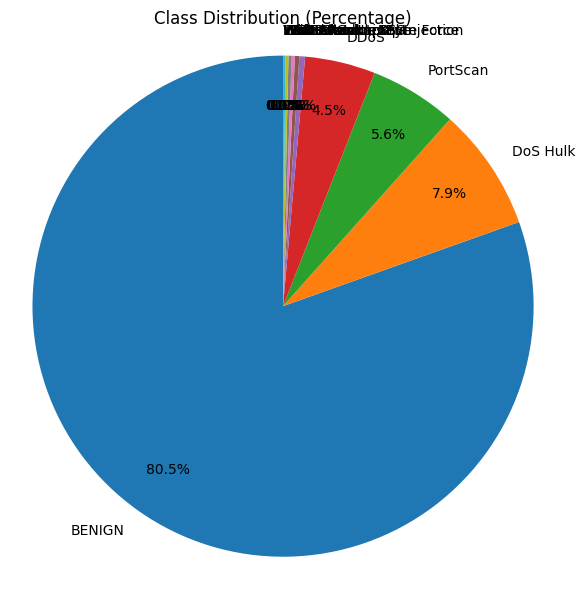

In [14]:
label_dist_pd = label_dist.to_pandas()

plt.figure(figsize=(6, 6))
plt.pie(
    label_dist_pd["len"],
    labels=label_dist_pd[label_col],
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.8
)
plt.title("Class Distribution (Percentage)")
plt.axis("equal")
plt.tight_layout()
plt.show()

In [19]:
rate_features = [
    "Flow_Bytes/s",
    "Flow_Packets/s"
]

existing_rate_features = [
    c for c in rate_features
    if c in df_final.columns
]


y = df[LABEL_COL].to_numpy()

global_attack_ratio = (y != BENIGN_LABEL).mean()

print("Global attack ratio:", global_attack_ratio)

for c in rate_features:
    if c not in df.columns:
        print(f"{c}: not found")
        continue

    x = df[c].to_numpy()

    valid_mask = np.isfinite(x)
    invalid_mask = ~valid_mask

    valid_attack_ratio = (y[valid_mask] != BENIGN_LABEL).mean() if valid_mask.sum() > 0 else None
    invalid_attack_ratio = (y[invalid_mask] != BENIGN_LABEL).mean() if invalid_mask.sum() > 0 else None

    print("\nFeature:", c)
    print("Valid rows:", valid_mask.sum())
    print("Invalid rows:", invalid_mask.sum())
    print("Attack ratio on valid rows:", valid_attack_ratio)
    print("Attack ratio on invalid rows:", invalid_attack_ratio)

Global attack ratio: 0.19547784626582207

Feature: Flow_Bytes/s
Valid rows: 2810958
Invalid rows: 2834
Attack ratio on valid rows: 0.19529569634267036
Attack ratio on invalid rows: 0.3761467889908257

Feature: Flow_Packets/s
Valid rows: 2810958
Invalid rows: 2834
Attack ratio on valid rows: 0.19529569634267036
Attack ratio on invalid rows: 0.3761467889908257


In [22]:
col_a = "Flow_Bytes/s"
col_b = "Flow_Packets/s"

invalid_expr_a = (
    pl.col(col_a).is_null() |
    pl.col(col_a).is_nan() |
    pl.col(col_a).is_infinite()
)

invalid_expr_b = (
    pl.col(col_b).is_null() |
    pl.col(col_b).is_nan() |
    pl.col(col_b).is_infinite()
)

invalid_expr_any = invalid_expr_a | invalid_expr_b
invalid_expr_both = invalid_expr_a & invalid_expr_b

In [24]:
invalid_summary = df.select([
    pl.len().alias("total_rows"),

    invalid_expr_a.sum().alias("Flow_Bytes_s_invalid_rows"),
    invalid_expr_b.sum().alias("Flow_Packets_s_invalid_rows"),
    invalid_expr_any.sum().alias("Any_invalid_rows"),
    invalid_expr_both.sum().alias("Both_invalid_rows"),

    pl.col(col_a).is_null().sum().alias("Flow_Bytes_s_null"),
    pl.col(col_a).is_nan().sum().alias("Flow_Bytes_s_nan"),
    pl.col(col_a).is_infinite().sum().alias("Flow_Bytes_s_inf"),

    pl.col(col_b).is_null().sum().alias("Flow_Packets_s_null"),
    pl.col(col_b).is_nan().sum().alias("Flow_Packets_s_nan"),
    pl.col(col_b).is_infinite().sum().alias("Flow_Packets_s_inf"),
])

print(invalid_summary)

shape: (1, 11)
┌────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┐
│ total_ ┆ Flow_B ┆ Flow_P ┆ Any_in ┆ Both_i ┆ Flow_B ┆ Flow_B ┆ Flow_B ┆ Flow_P ┆ Flow_P ┆ Flow_P │
│ rows   ┆ ytes_s ┆ ackets ┆ valid_ ┆ nvalid ┆ ytes_s ┆ ytes_s ┆ ytes_s ┆ ackets ┆ ackets ┆ ackets │
│ ---    ┆ _inval ┆ _s_inv ┆ rows   ┆ _rows  ┆ _null  ┆ _nan   ┆ _inf   ┆ _s_nul ┆ _s_nan ┆ _s_inf │
│ u32    ┆ id_row ┆ alid_r ┆ ---    ┆ ---    ┆ ---    ┆ ---    ┆ ---    ┆ l      ┆ ---    ┆ ---    │
│        ┆ s      ┆ ows    ┆ u32    ┆ u32    ┆ u32    ┆ u32    ┆ u32    ┆ ---    ┆ u32    ┆ u32    │
│        ┆ ---    ┆ ---    ┆        ┆        ┆        ┆        ┆        ┆ u32    ┆        ┆        │
│        ┆ u32    ┆ u32    ┆        ┆        ┆        ┆        ┆        ┆        ┆        ┆        │
╞════════╪════════╪════════╪════════╪════════╪════════╪════════╪════════╪════════╪════════╪════════╡
│ 281379 ┆ 2834   ┆ 2834   ┆ 2834   ┆ 2834   ┆ 1333   ┆ 0      ┆ 1501   ┆ 0 

In [26]:
invalid_label_dist = (
    df
    .filter(invalid_expr_any)
    .group_by(label_col)
    .len()
    .with_columns(
        (pl.col("len") / pl.sum("len")).alias("ratio")
    )
    .sort("len", descending=True)
)

print(invalid_label_dist)

shape: (6, 3)
┌─────────────┬──────┬──────────┐
│ Label       ┆ len  ┆ ratio    │
│ ---         ┆ ---  ┆ ---      │
│ str         ┆ u32  ┆ f64      │
╞═════════════╪══════╪══════════╡
│ BENIGN      ┆ 1768 ┆ 0.623853 │
│ DoS Hulk    ┆ 925  ┆ 0.326394 │
│ PortScan    ┆ 126  ┆ 0.04446  │
│ Bot         ┆ 10   ┆ 0.003529 │
│ FTP-Patator ┆ 3    ┆ 0.001059 │
│ DDoS        ┆ 2    ┆ 0.000706 │
└─────────────┴──────┴──────────┘


In [27]:
valid_df = df.filter(~invalid_expr_any)

print("Valid rows:", valid_df.height)


Valid rows: 2810958


In [28]:
corr_valid = (
    valid_df
    .select([col_a, col_b])
    .corr()
)

print(corr_valid)

shape: (2, 2)
┌──────────────┬────────────────┐
│ Flow_Bytes/s ┆ Flow_Packets/s │
│ ---          ┆ ---            │
│ f64          ┆ f64            │
╞══════════════╪════════════════╡
│ 1.0          ┆ 0.225626       │
│ 0.225626     ┆ 1.0            │
└──────────────┴────────────────┘


In [30]:
target_cols = ["Flow_Bytes/s", "Flow_Packets/s"]

for c in target_cols:
    if c in mi_scores:
        rank = [x[0] for x in mi_ranked].index(c) + 1
        print(c)
        print("MI:", mi_scores[c])
        print

Flow_Bytes/s
MI: 0.29102864972080167
Flow_Packets/s
MI: 0.28757497397977777


In [29]:
same_invalid_pattern = (
    df
    .select((invalid_expr_a == invalid_expr_b).all())
    .item()
)

print("Invalid patterns identical:", same_invalid_pattern)

Invalid patterns identical: True


In [34]:
flow_bytes_null_label_dist = (
    df
    .filter(pl.col("Flow_Bytes/s").is_null())
    .group_by(label_col)
    .len()
    .with_columns(
        (pl.col("len") / pl.sum("len")).alias("ratio")
    )
    .sort("len", descending=True)
)

print(flow_bytes_null_label_dist)

flow_bytes_infinite_label_dist = (
    df
    .filter(pl.col("Flow_Bytes/s").is_infinite())
    .group_by(label_col)
    .len()
    .with_columns(
        (pl.col("len") / pl.sum("len")).alias("ratio")
    )
    .sort("len", descending=True)
)

print(flow_bytes_infinite_label_dist)


shape: (2, 3)
┌──────────┬─────┬──────────┐
│ Label    ┆ len ┆ ratio    │
│ ---      ┆ --- ┆ ---      │
│ str      ┆ u32 ┆ f64      │
╞══════════╪═════╪══════════╡
│ DoS Hulk ┆ 925 ┆ 0.693923 │
│ BENIGN   ┆ 408 ┆ 0.306077 │
└──────────┴─────┴──────────┘
shape: (5, 3)
┌─────────────┬──────┬──────────┐
│ Label       ┆ len  ┆ ratio    │
│ ---         ┆ ---  ┆ ---      │
│ str         ┆ u32  ┆ f64      │
╞═════════════╪══════╪══════════╡
│ BENIGN      ┆ 1360 ┆ 0.906063 │
│ PortScan    ┆ 126  ┆ 0.083944 │
│ Bot         ┆ 10   ┆ 0.006662 │
│ FTP-Patator ┆ 3    ┆ 0.001999 │
│ DDoS        ┆ 2    ┆ 0.001332 │
└─────────────┴──────┴──────────┘


In [38]:
flow_bytes_col = "Flow_Bytes/s"
flow_packets_col = "Flow_Packets/s"

# Drop Flow_Packets/s to save token space
if flow_packets_col in df.columns:
    df_final = df_final.drop(flow_packets_col)

# Convert Flow_Bytes/s into compact string feature
df_final = df_final.with_columns(
    pl.when(pl.col(flow_bytes_col).is_null())
      .then(pl.lit("NULL"))

    # Treat NaN like NULL, because it is also a missing/invalid numeric state
    .when(pl.col(flow_bytes_col).is_nan())
      .then(pl.lit("NULL"))

    # Positive infinity
    .when(pl.col(flow_bytes_col) == float("inf"))
      .then(pl.lit("INF"))

    # Negative infinity, just in case
    .when(pl.col(flow_bytes_col) == float("-inf"))
      .then(pl.lit("-INF"))

    # Valid numeric values: round to 3 decimals and convert to string
    .otherwise(
        pl.col(flow_bytes_col)
          .round(3)
          .cast(pl.Utf8)
    )
    .alias(flow_bytes_col)
)

InvalidOperationError: `is_nan` operation not supported for dtype `str`

In [47]:
df_final = df_final.drop("Timestamp")

In [44]:
special_value_counts = (
    df
    .filter(pl.col(flow_bytes_col).is_in(["NULL", "INF", "-INF"]))
    .group_by(flow_bytes_col)
    .len()
    .sort("len", descending=True)
)

print(special_value_counts)

shape: (2, 2)
┌──────────────┬──────┐
│ Flow_Bytes/s ┆ len  │
│ ---          ┆ ---  │
│ str          ┆ u32  │
╞══════════════╪══════╡
│ INF          ┆ 1501 │
│ NULL         ┆ 1333 │
└──────────────┴──────┘


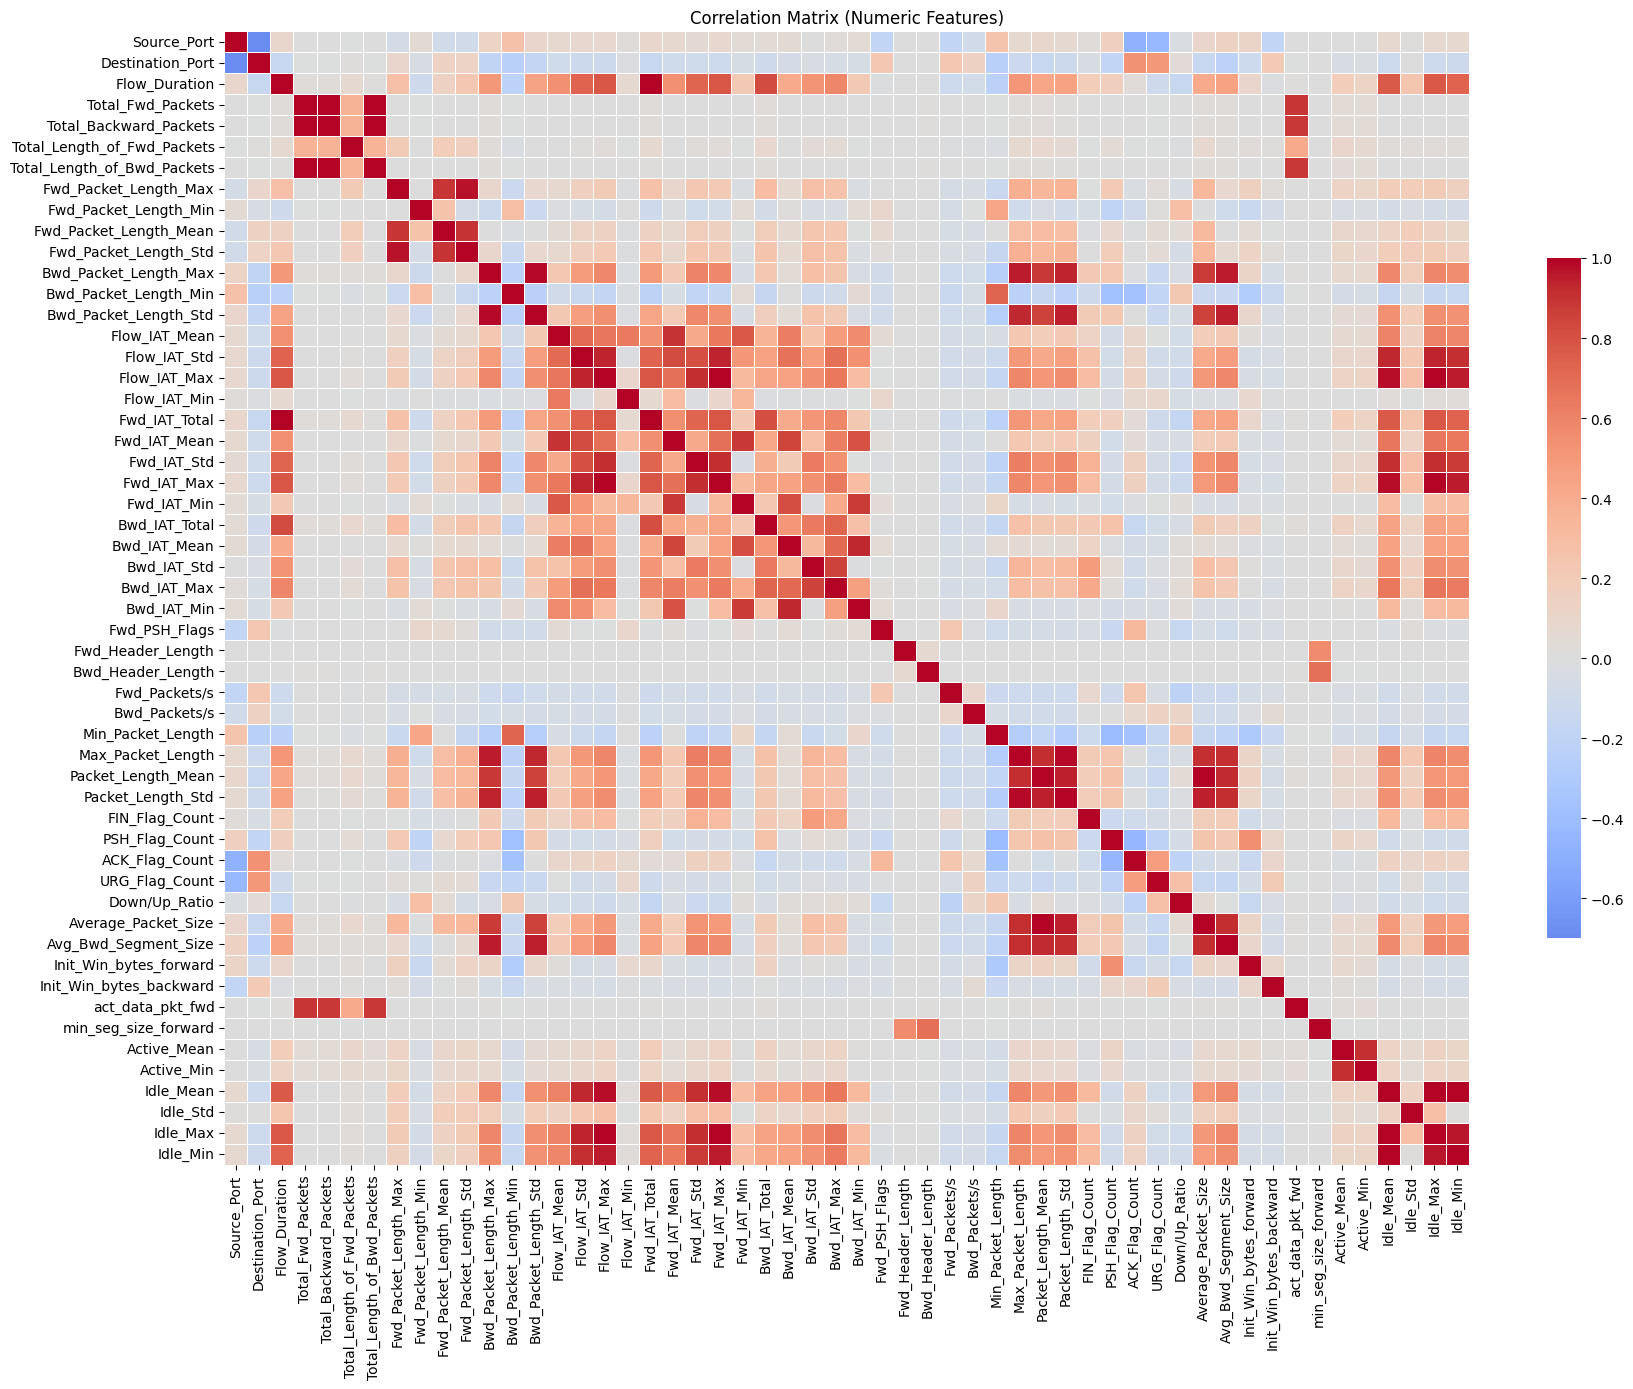

In [41]:
# Correlation Heatmap (Numeric Features)
# Convert only numeric subset for correlation

# Select numeric columns only, excluding Label
numeric_cols = [
    c for c, dtype in zip(df_final.columns, df_final.dtypes)
    if c != "Label" and dtype in [
        pl.Int8, pl.Int16, pl.Int32, pl.Int64,
        pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
        pl.Float32, pl.Float64
    ]
]

# Compute correlation matrix using Polars
corr_pl = df_final.select(numeric_cols).corr()

# Convert only correlation matrix to pandas for seaborn
corr_pd = corr_pl.to_pandas()

# Polars corr() loses column/index labels in pandas index sometimes,
# so explicitly set both index and columns
corr_pd.index = numeric_cols
corr_pd.columns = numeric_cols

plt.figure(figsize=(18, 14))

sns.heatmap(
    corr_pd,
    cmap="coolwarm",
    center=0,
    linewidths=0.4,
    cbar_kws={"shrink": 0.6}
)

plt.title("Correlation Matrix (Numeric Features)")
plt.tight_layout()
plt.show()


In [48]:
df_final.columns

['Source_Port',
 'Destination_Port',
 'Flow_Duration',
 'Total_Fwd_Packets',
 'Total_Backward_Packets',
 'Total_Length_of_Fwd_Packets',
 'Total_Length_of_Bwd_Packets',
 'Fwd_Packet_Length_Max',
 'Fwd_Packet_Length_Min',
 'Fwd_Packet_Length_Mean',
 'Fwd_Packet_Length_Std',
 'Bwd_Packet_Length_Max',
 'Bwd_Packet_Length_Min',
 'Bwd_Packet_Length_Std',
 'Flow_Bytes/s',
 'Flow_IAT_Mean',
 'Flow_IAT_Std',
 'Flow_IAT_Max',
 'Flow_IAT_Min',
 'Fwd_IAT_Total',
 'Fwd_IAT_Mean',
 'Fwd_IAT_Std',
 'Fwd_IAT_Max',
 'Fwd_IAT_Min',
 'Bwd_IAT_Total',
 'Bwd_IAT_Mean',
 'Bwd_IAT_Std',
 'Bwd_IAT_Max',
 'Bwd_IAT_Min',
 'Fwd_PSH_Flags',
 'Fwd_Header_Length',
 'Bwd_Header_Length',
 'Fwd_Packets/s',
 'Bwd_Packets/s',
 'Min_Packet_Length',
 'Max_Packet_Length',
 'Packet_Length_Mean',
 'Packet_Length_Std',
 'FIN_Flag_Count',
 'PSH_Flag_Count',
 'ACK_Flag_Count',
 'URG_Flag_Count',
 'Down/Up_Ratio',
 'Average_Packet_Size',
 'Avg_Bwd_Segment_Size',
 'Init_Win_bytes_forward',
 'Init_Win_bytes_backward',
 'act_data_p

In [50]:
# Save Polars DataFrame as Parquet (all columns, compressed, fast)
df_final.write_parquet("cicids2017_after_feature_reduction.parquet")
print("DataFrame saved to cicids2017_after_feature_reduction.parquet")

DataFrame saved to cicids2017_after_feature_reduction.parquet
